In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler



In [ ]:
!unzip /content/Magic_Dataset.zip

Archive:  /content/Magic_Dataset.zip
  inflating: telescope_data.csv      


In [ ]:
import pandas as pd
df=pd.read_csv("/content/telescope_data.csv")
df

,Unnamed: 0,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g
...,...,...,...,...,...,...,...,...,...,...,...,...
19015,19015,21.3846,10.9170,2.6161,0.5857,0.3934,15.2618,11.5245,2.8766,2.4229,106.8258,h
19016,19016,28.9452,6.7020,2.2672,0.5351,0.2784,37.0816,13.1853,-2.9632,86.7975,247.4560,h
19017,19017,75.4455,47.5305,3.4483,0.1417,0.0549,-9.3561,41.0562,-9.4662,30.2987,256.5166,h
19018,19018,120.5135,76.9018,3.9939,0.0944,0.0683,5.8043,-93.5224,-63.8389,84.6874,408.3166,h


In [ ]:
df["class"].unique()
#Our computers they don't understand letters
#they better understand numbers in next cell we
#will convert from letter to binary numbers

array(['g', 'h'], dtype=object)

In [ ]:
df["class"]=(df["class"]=="g").astype(int)
#IF class ==g then store 1 else store 0


In [ ]:
df['class'].unique()

array([1, 0])

In [ ]:
df.head()

,Unnamed: 0,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
0,0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,1
1,1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,1
2,2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,1
3,3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,1
4,4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,1


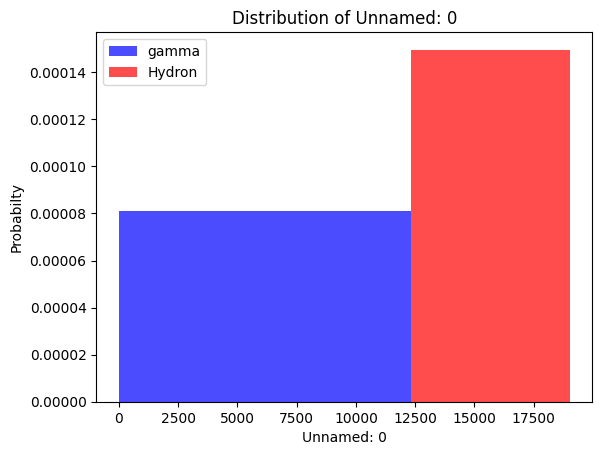

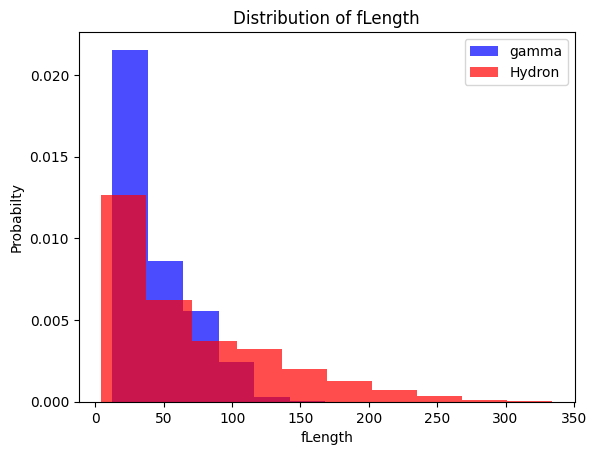

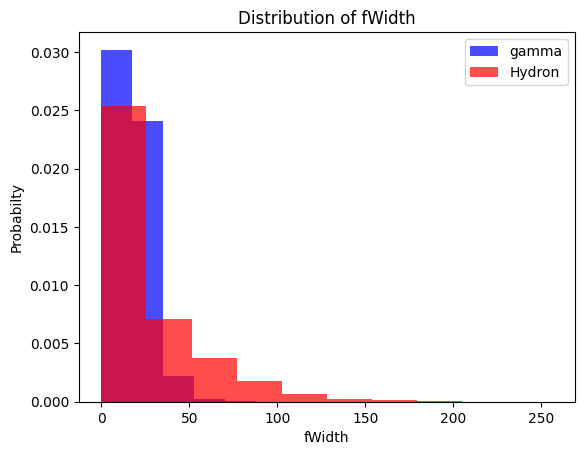

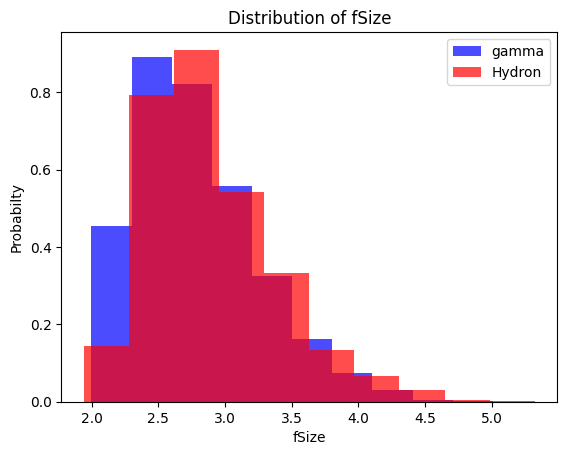

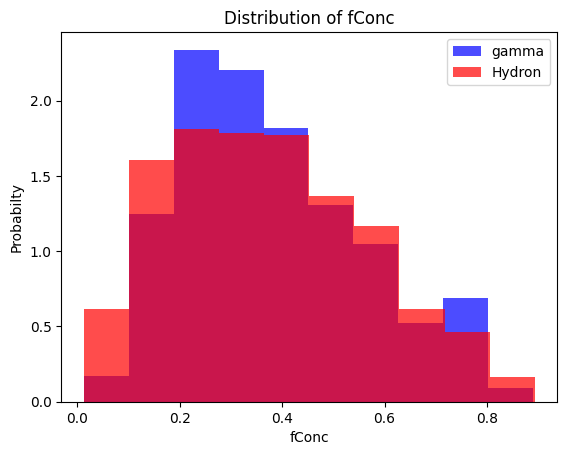

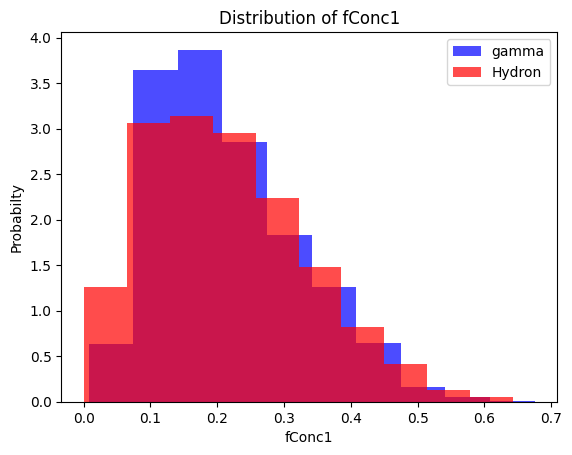

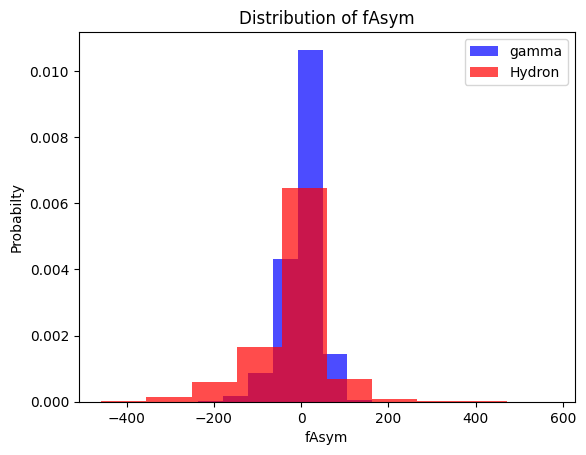

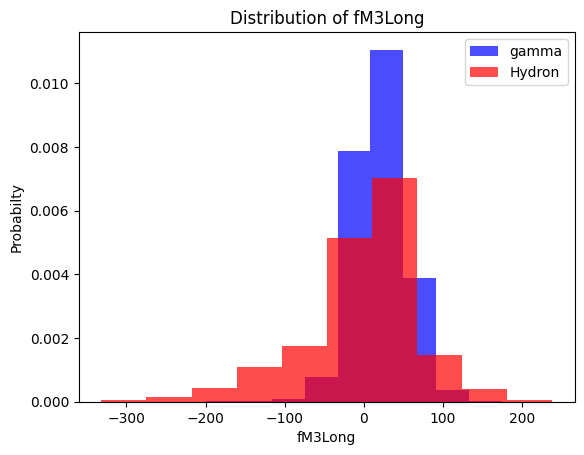

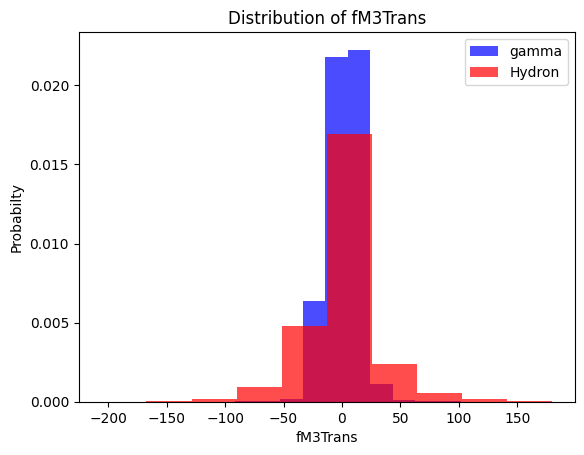

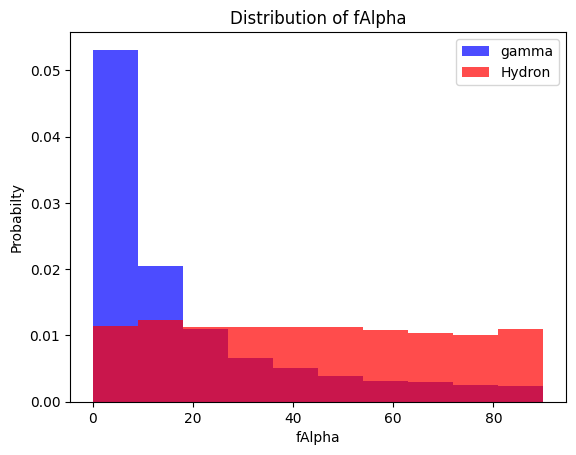

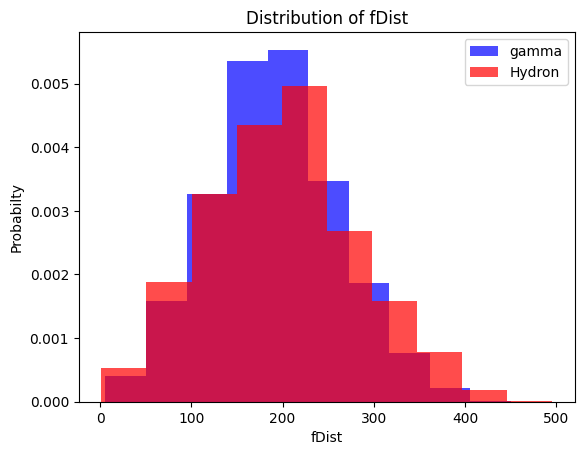

In [ ]:
for feature in df.columns[:-1]: #loop over all features except class
  plt.hist(df[df["class"]==1][feature],color='blue',label='gamma',alpha=0.7,density=True)
  plt.hist(df[df["class"]==0][feature],color='red',label='Hydron',alpha=0.7,density=True)
  plt.xlabel(feature)
  plt.ylabel("Probabilty")
  plt.title(f"Distribution of {feature}")
  plt.legend()
  plt.show()



In [ ]:
train,valid,test=np.split(df.sample(frac=1),[int(0.6*len(df)),int(0.8*len(df))])
"""
Split	Rows
train	0 → 11412 (60%)
valid	11412 → 15216 (20%)
test	15216 → end (20%)
"""


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


'\nSplit\tRows\ntrain\t0 → 11412 (60%)\nvalid\t11412 → 15216 (20%)\ntest\t15216 → end (20%)\n'

In [ ]:
def scale_dataset(dataframe,OverSample=False):
	X = dataframe.drop(columns=['Unnamed: 0', 'class']).values
	y=dataframe[dataframe.columns[-1]].values # take only class label

	scaler=StandardScaler() #calculates mean and standard deviation of dataset
	X=scaler.fit_transform(X)#Does mean and standard deviation for each column then transform all in one step
	if OverSample:
		ros=RandomOverSampler()
		X,y=ros.fit_resample(X,y)
	data=np.hstack((X,np.reshape(y,(-1,1))))
	return data,X,y
 #This part it first reshapes y to be column vector of 1 column as first it was only (samples,) now it is (samples,1)
 #so we can stack X train and y label horizontally to train model



In [ ]:
train

,Unnamed: 0,fLength,fWidth,fSize,fConc,fConc1,fAsym,fM3Long,fM3Trans,fAlpha,fDist,class
11752,11752,22.4940,12.1301,2.3856,0.6132,0.3560,18.5438,13.4683,-10.1801,52.9170,141.9720,1
13936,13936,93.3756,56.9617,3.3768,0.1600,0.0825,-7.6621,18.5969,32.2942,47.4540,332.2960,0
6447,6447,33.4992,22.9809,2.8768,0.3015,0.1627,1.0433,30.3014,16.2923,33.6328,192.5220,1
18784,18784,50.6802,28.7824,2.6677,0.3253,0.1733,39.5190,48.5249,-34.7856,87.1475,145.3108,0
14168,14168,49.0238,9.7021,2.7649,0.4089,0.2225,-44.8007,-29.8157,5.3320,8.0425,137.4630,0
...,...,...,...,...,...,...,...,...,...,...,...,...
733,733,93.0607,28.3185,3.5398,0.1160,0.0622,-127.3420,56.0140,-10.9973,3.7370,233.6730,1
11634,11634,71.0454,31.5358,3.4100,0.1988,0.1017,47.2843,70.4096,19.5975,4.3480,264.3540,1
661,661,37.0979,8.0876,2.5809,0.4908,0.2585,-10.8717,25.3223,10.9802,1.4720,169.1770,1
2034,2034,44.6257,17.3928,2.7846,0.2726,0.1404,10.0460,36.8161,13.2095,19.3827,175.4130,1


In [ ]:
print(len(train[train['class']==1]))
print(len(train[train['class']==0]))
#Imbalanced data is very obvious here as training size for
#If class ==gamma  store 1
#if class ==hadron store 0
#gamma samples is 7387
#hydron samples is 4025

7426
3986


In [ ]:
#Here i will be using RandomOverSampler function where this function
#Does duplicate minority class until they match majority class
#The thing which RandomOverSampler is that it makes model see same sample many times
#in my opinion this increases chances of overfitting
#but this is trade off as iF MODEL saw alot of gamma model might learn to predict gamma only
#and ignore hadron class
#This will be used just for experiencing with function in real world senarios maybe other stuff
#could be more usefull such as trying to balance data by collectiong more data


In [ ]:
train,X_train,Y_train=scale_dataset(train,OverSample=True)
valid,X_valid,Y_valid=scale_dataset(valid,OverSample=False)
test,X_test,Y_test=scale_dataset(test,OverSample=False)

In [ ]:
X_train.shape

(14852, 10)

In [ ]:
len(Y_train)

14852

In [ ]:
print(sum(Y_train==1))
print(sum(Y_train==0))
#Now Both classes are balanced after OverSampling

7426
7426


Now We will start training models we will start with
KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report


In [ ]:
#Unlike other models and neural networks Knn just memorize training points along with their labels
#when new point is entered it just compares test point with training points
knn_model=KNeighborsClassifier(n_neighbors=1)
knn_model.fit(X_train,Y_train)

KNeighborsClassifier(n_neighbors=1)

In [ ]:
#lets predict on test data
y_pred=knn_model.predict(X_test)
print(classification_report(Y_test,y_pred))
#Video stopped at 55:45

              precision    recall  f1-score   support

           0       0.77      0.67      0.72      1372
           1       0.83      0.89      0.86      2432

    accuracy                           0.81      3804
   macro avg       0.80      0.78      0.79      3804
weighted avg       0.81      0.81      0.81      3804



In [ ]:

#Train with 3 Neigbours
knn_model=KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train,Y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
#lets predict on test data
y_pred=knn_model.predict(X_test)
print(classification_report(Y_test,y_pred))
#Video stopped at 55:45

              precision    recall  f1-score   support

           0       0.73      0.72      0.72      1372
           1       0.84      0.85      0.84      2432

    accuracy                           0.80      3804
   macro avg       0.78      0.78      0.78      3804
weighted avg       0.80      0.80      0.80      3804



In [ ]:

#Train with 5 Neigbours
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train,Y_train)

KNeighborsClassifier()

In [ ]:
#lets predict on test data
y_pred=knn_model.predict(X_test)
print(classification_report(Y_test,y_pred))
#Video stopped at 55:45

              precision    recall  f1-score   support

           0       0.74      0.73      0.73      1372
           1       0.85      0.86      0.85      2432

    accuracy                           0.81      3804
   macro avg       0.80      0.79      0.79      3804
weighted avg       0.81      0.81      0.81      3804



In [ ]:
#Naive Bayes Classifier
from sklearn.naive_bayes import GaussianNB

nb_model=GaussianNB()
nb_model.fit(X_train,Y_train)
#

GaussianNB()

In [ ]:
y_pred=nb_model.predict(X_test)
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           0       0.68      0.40      0.51      1372
           1       0.73      0.90      0.80      2432

    accuracy                           0.72      3804
   macro avg       0.71      0.65      0.65      3804
weighted avg       0.71      0.72      0.70      3804



In [ ]:
#Logistic Regression Classifier
from sklearn.linear_model import LogisticRegression

In [ ]:
lg_model=LogisticRegression()
lg_model=lg_model.fit(X_train,Y_train)

In [ ]:
y_pred=lg_model.predict(X_test)
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           0       0.70      0.71      0.70      1372
           1       0.84      0.82      0.83      2432

    accuracy                           0.78      3804
   macro avg       0.77      0.77      0.77      3804
weighted avg       0.79      0.78      0.78      3804



In [ ]:
from sklearn.svm import SVC

svm_model=SVC()
svm_model=svm_model.fit(X_train,Y_train)

In [ ]:
y_pred=svm_model.predict(X_test)
print(classification_report(Y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1372
           1       0.89      0.89      0.89      2432

    accuracy                           0.86      3804
   macro avg       0.85      0.85      0.85      3804
weighted avg       0.86      0.86      0.86      3804



In [ ]:
import matplotlib.pyplot as plt

def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2)

    # Loss plot
    ax1.plot(history.history['loss'], label='loss')
    ax1.plot(history.history['val_loss'], label='val_loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Binary crossentropy')
    ax1.legend()
    ax1.grid(True)

    # Accuracy plot
    ax2.plot(history.history['accuracy'], label='accuracy')
    ax2.plot(history.history['val_accuracy'], label='val_accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)

    plt.show()

In [ ]:
import tensorflow as tf

def train_model(X_train,Y_train,num_nodes,dropout_prob,lr,batch_size,epochs):
  nn_model = tf.keras.Sequential([
      tf.keras.layers.Dense(num_nodes, activation='relu', input_shape=(10,)),
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(num_nodes, activation='relu'),
      tf.keras.layers.Dropout(dropout_prob),
      tf.keras.layers.Dense(1, activation='sigmoid')
  ])

  nn_model.compile(
      optimizer=tf.keras.optimizers.Adam(lr),
      loss='binary_crossentropy',
      metrics=['accuracy']
  )
  history=nn_model.fit(X_train,Y_train,epochs,batch_size,validation_split=0.2,verbose=0)

  return nn_model,history

16nodes,dropout=0,Learning Rate=0.01,Batch Size=32


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


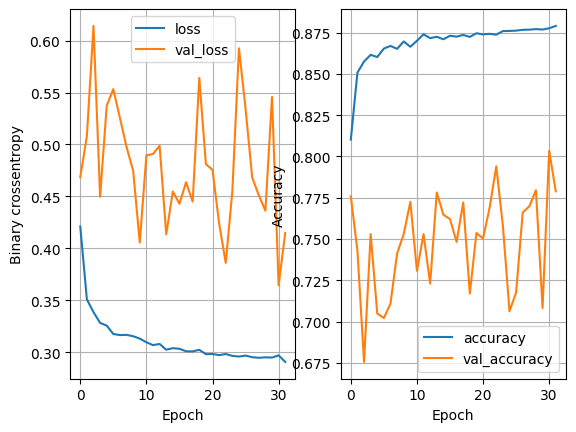

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8609 - loss: 0.3232
16nodes,dropout=0,Learning Rate=0.01,Batch Size=64


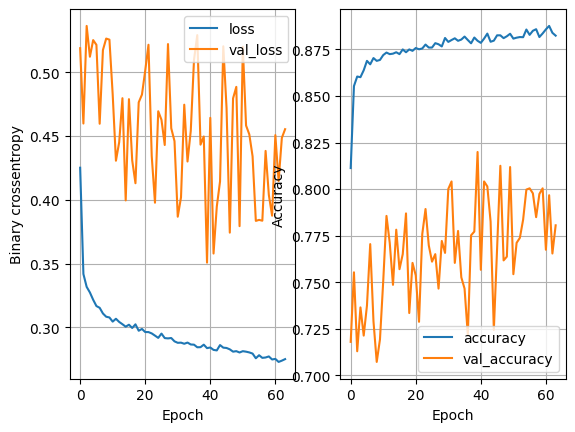

119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8620 - loss: 0.3238
16nodes,dropout=0,Learning Rate=0.01,Batch Size=128


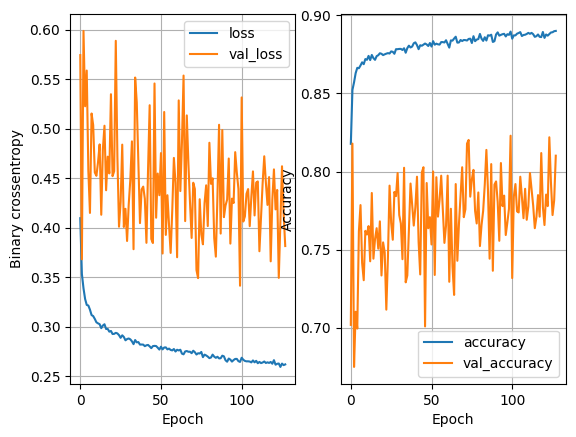

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8644 - loss: 0.3379
16nodes,dropout=0,Learning Rate=0.005,Batch Size=32


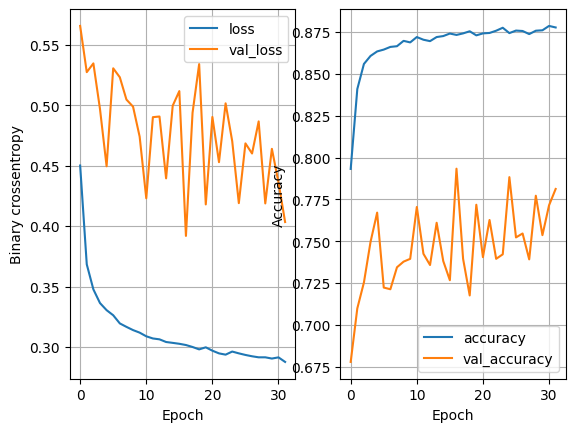

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8646 - loss: 0.3269
16nodes,dropout=0,Learning Rate=0.005,Batch Size=64


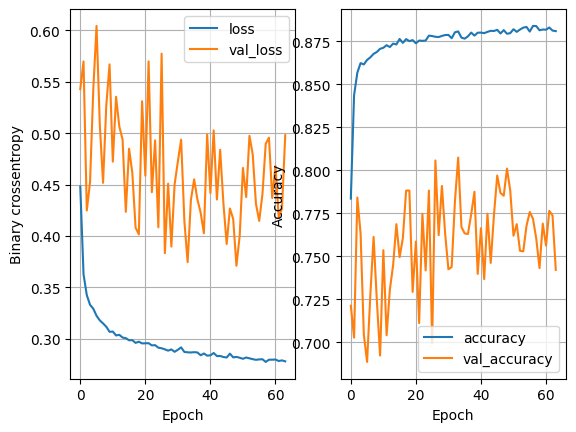

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8662 - loss: 0.3248
16nodes,dropout=0,Learning Rate=0.005,Batch Size=128


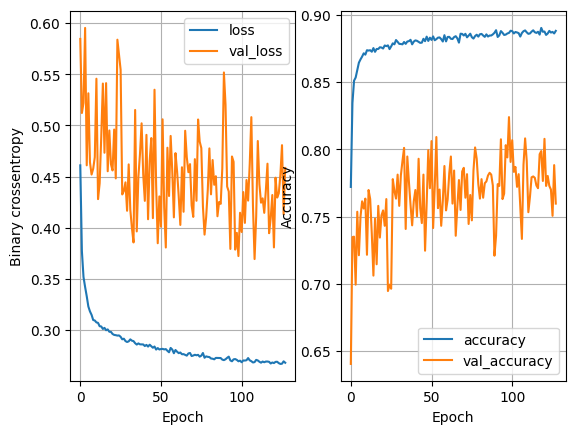

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8741 - loss: 0.3234
16nodes,dropout=0,Learning Rate=0.001,Batch Size=32


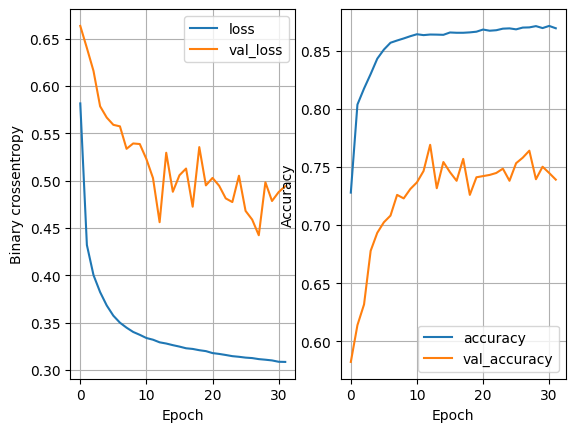

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8623 - loss: 0.3269
16nodes,dropout=0,Learning Rate=0.001,Batch Size=64


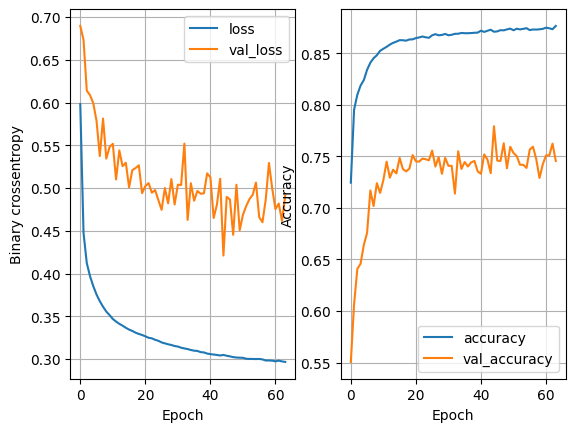

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8670 - loss: 0.3194
16nodes,dropout=0,Learning Rate=0.001,Batch Size=128


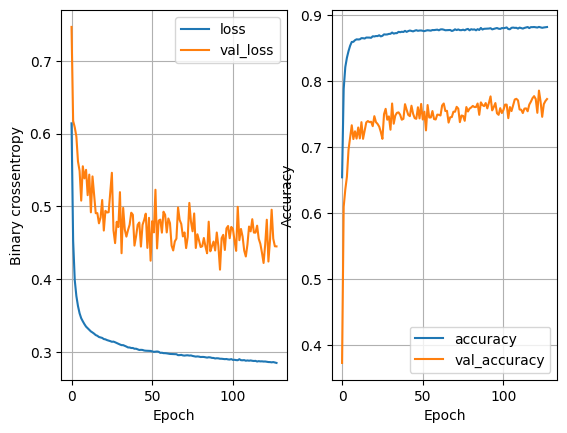

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8633 - loss: 0.3209
16nodes,dropout=0.2,Learning Rate=0.01,Batch Size=32


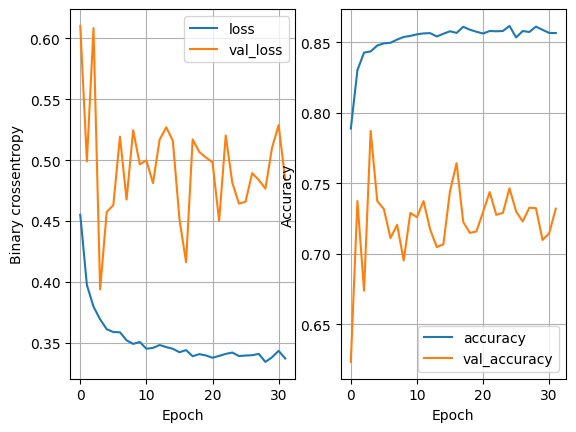

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8591 - loss: 0.3324
16nodes,dropout=0.2,Learning Rate=0.01,Batch Size=64


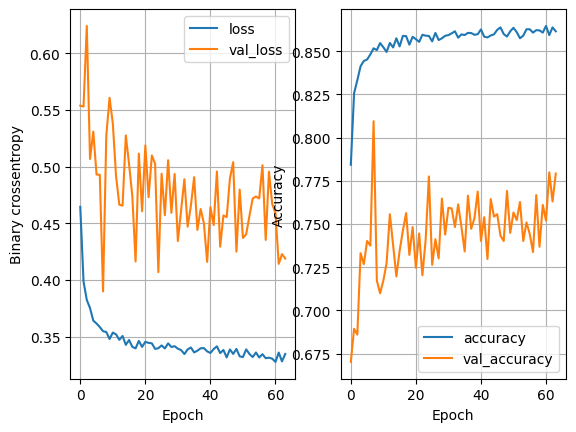

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8575 - loss: 0.3297
16nodes,dropout=0.2,Learning Rate=0.01,Batch Size=128


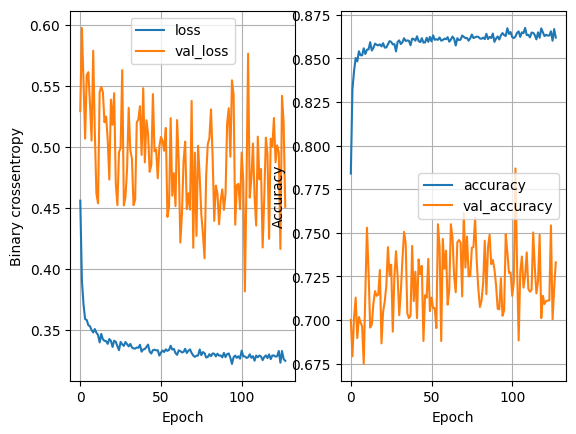

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8644 - loss: 0.3299
16nodes,dropout=0.2,Learning Rate=0.005,Batch Size=32


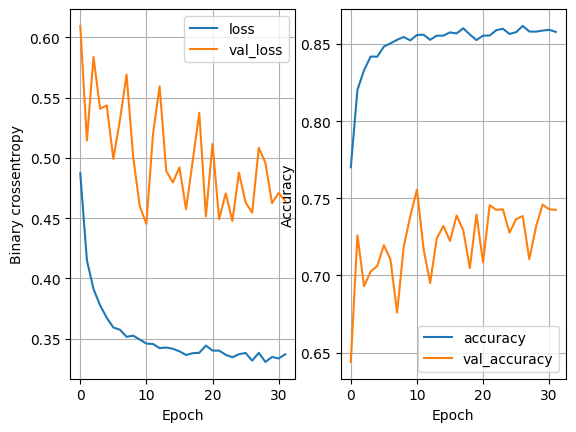

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8591 - loss: 0.3327
16nodes,dropout=0.2,Learning Rate=0.005,Batch Size=64


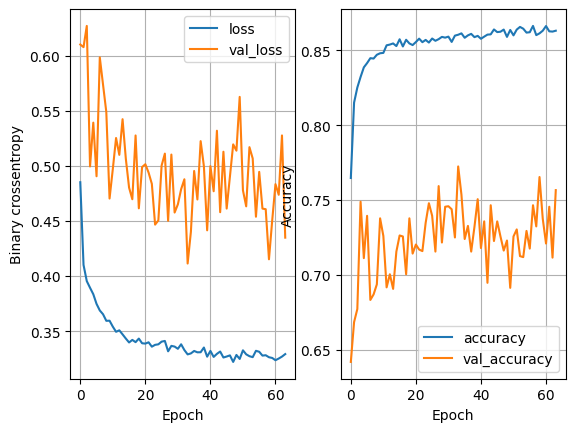

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8580 - loss: 0.3287
16nodes,dropout=0.2,Learning Rate=0.005,Batch Size=128


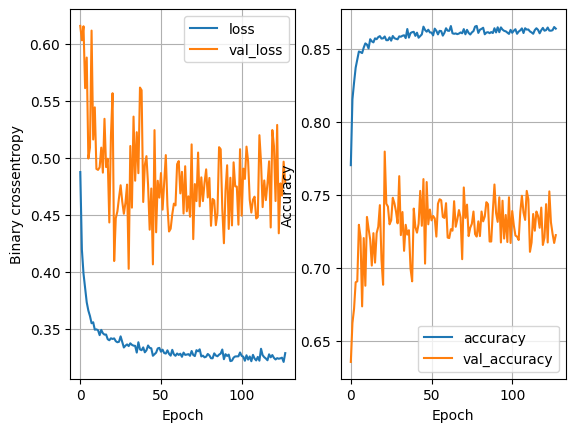

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8662 - loss: 0.3211
16nodes,dropout=0.2,Learning Rate=0.001,Batch Size=32


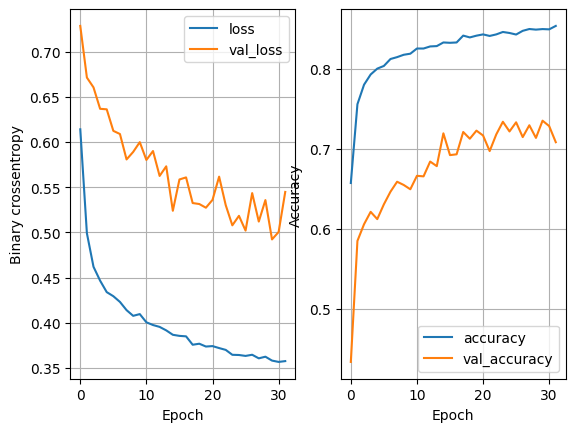

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8528 - loss: 0.3428
16nodes,dropout=0.2,Learning Rate=0.001,Batch Size=64


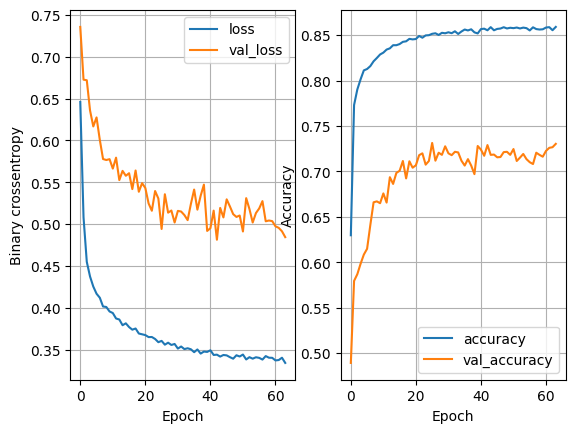

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8601 - loss: 0.3322
16nodes,dropout=0.2,Learning Rate=0.001,Batch Size=128


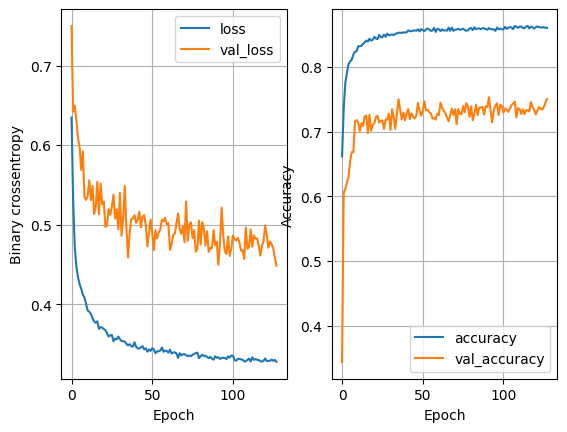

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8683 - loss: 0.3231
32nodes,dropout=0,Learning Rate=0.01,Batch Size=32


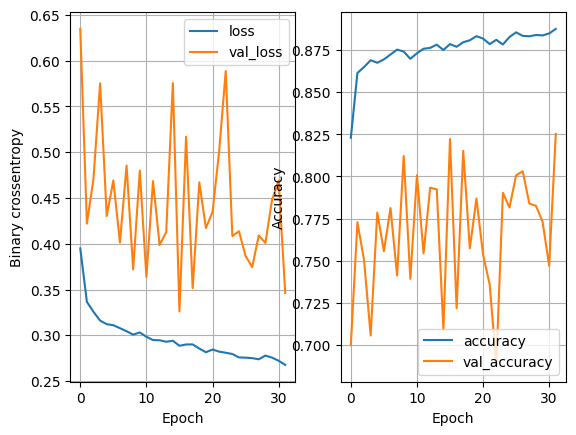

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8615 - loss: 0.3440
32nodes,dropout=0,Learning Rate=0.01,Batch Size=64


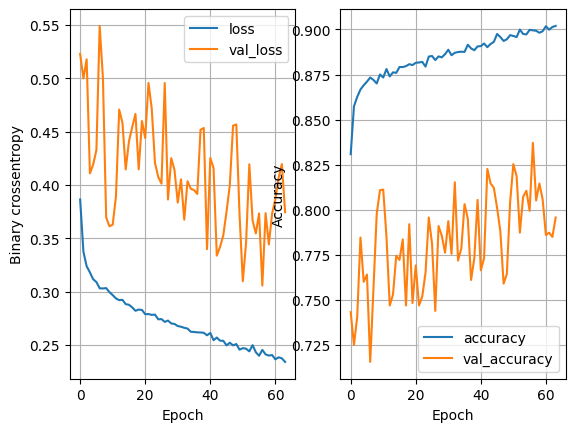

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8628 - loss: 0.3546
32nodes,dropout=0,Learning Rate=0.01,Batch Size=128


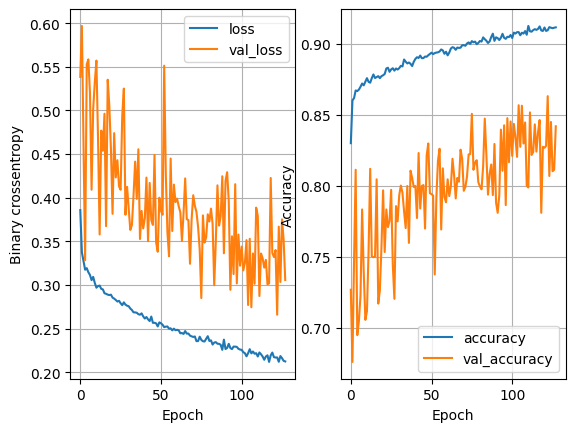

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8617 - loss: 0.4017
32nodes,dropout=0,Learning Rate=0.005,Batch Size=32


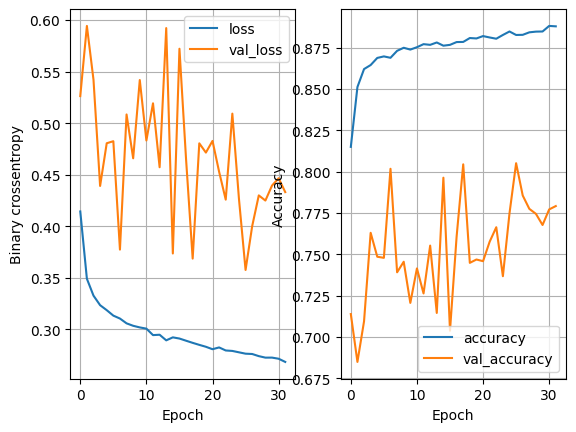

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8730 - loss: 0.3163
32nodes,dropout=0,Learning Rate=0.005,Batch Size=64


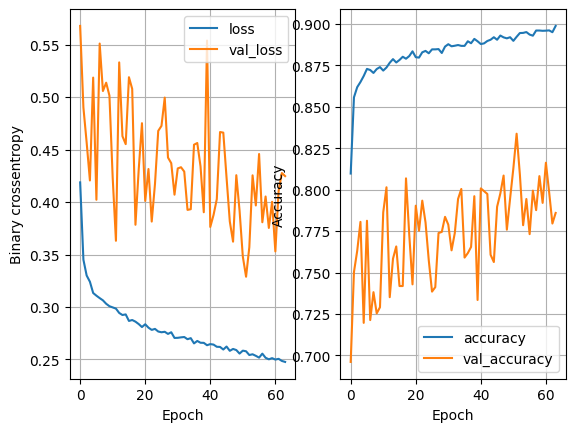

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8636 - loss: 0.3496
32nodes,dropout=0,Learning Rate=0.005,Batch Size=128


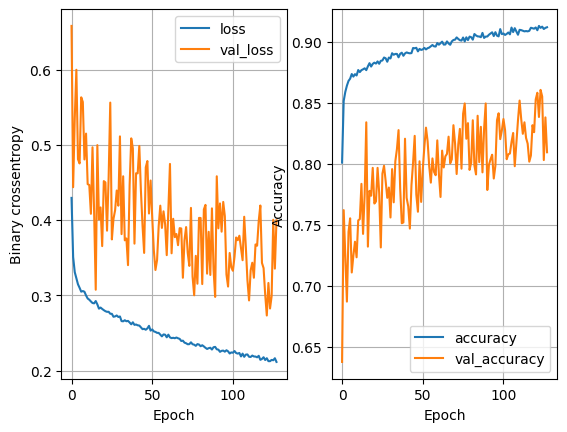

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8628 - loss: 0.3794
32nodes,dropout=0,Learning Rate=0.001,Batch Size=32


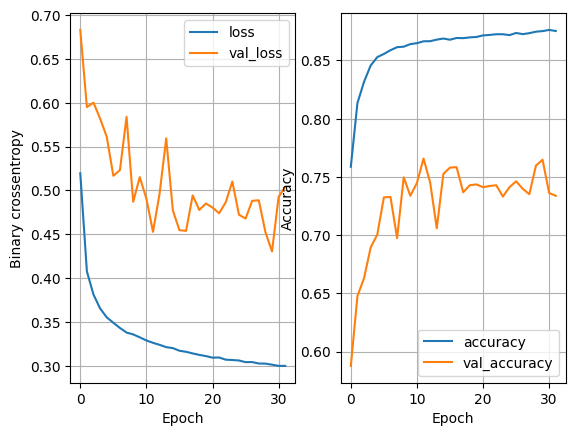

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8654 - loss: 0.3222
32nodes,dropout=0,Learning Rate=0.001,Batch Size=64


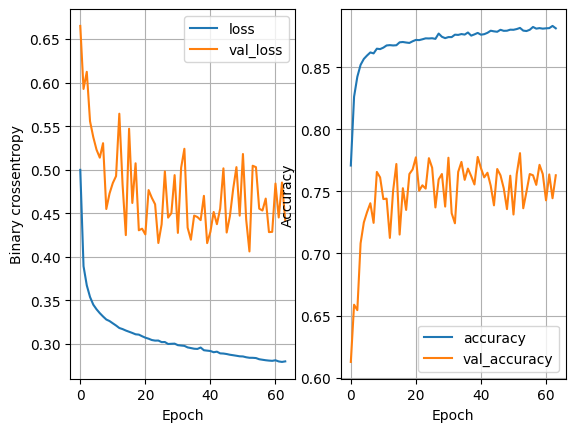

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8654 - loss: 0.3212
32nodes,dropout=0,Learning Rate=0.001,Batch Size=128


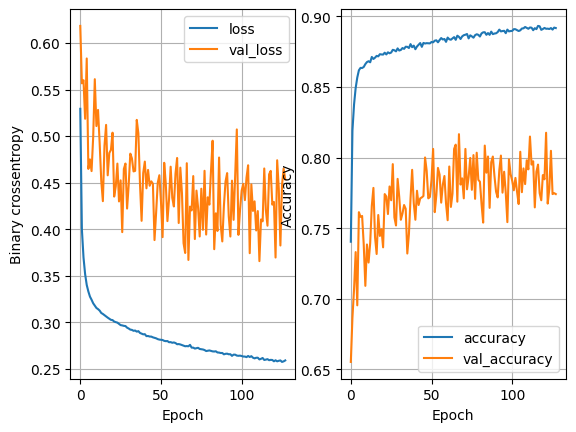

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8683 - loss: 0.3216
32nodes,dropout=0.2,Learning Rate=0.01,Batch Size=32


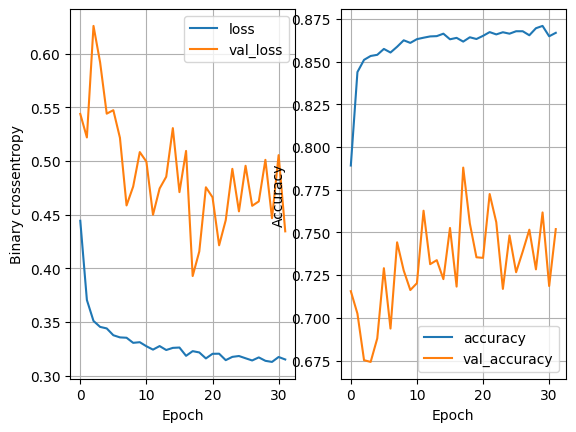

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8670 - loss: 0.3181
32nodes,dropout=0.2,Learning Rate=0.01,Batch Size=64


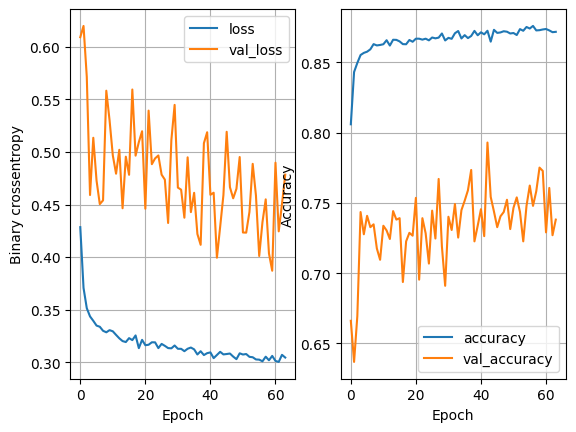

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8701 - loss: 0.3124
32nodes,dropout=0.2,Learning Rate=0.01,Batch Size=128


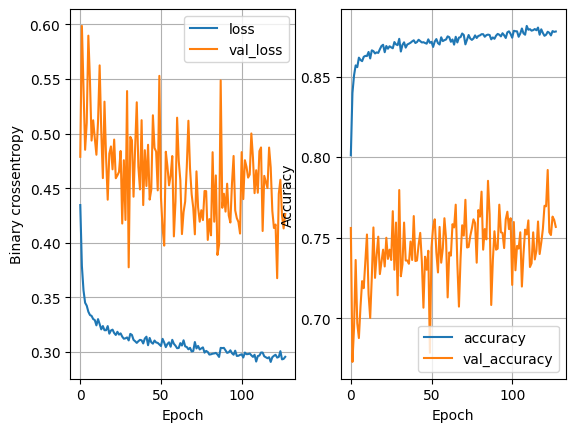

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8730 - loss: 0.3128
32nodes,dropout=0.2,Learning Rate=0.005,Batch Size=32


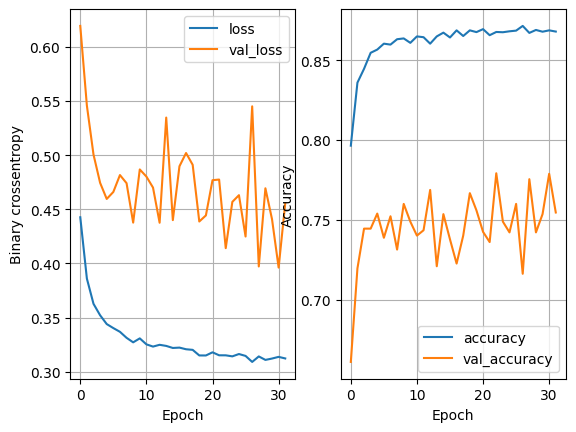

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8709 - loss: 0.3148
32nodes,dropout=0.2,Learning Rate=0.005,Batch Size=64


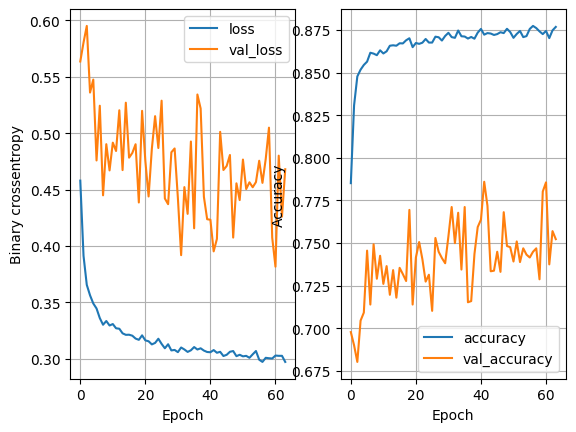

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8701 - loss: 0.3125
32nodes,dropout=0.2,Learning Rate=0.005,Batch Size=128


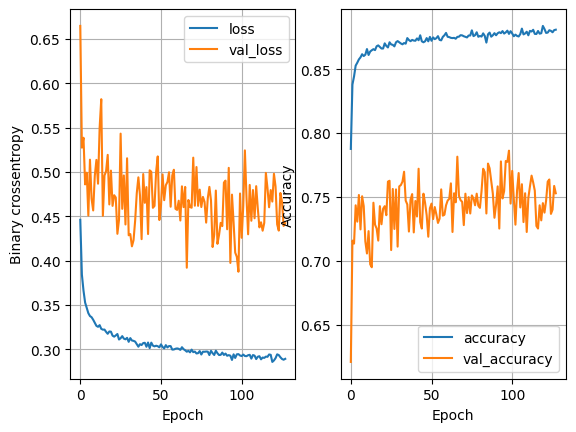

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8707 - loss: 0.3054
32nodes,dropout=0.2,Learning Rate=0.001,Batch Size=32


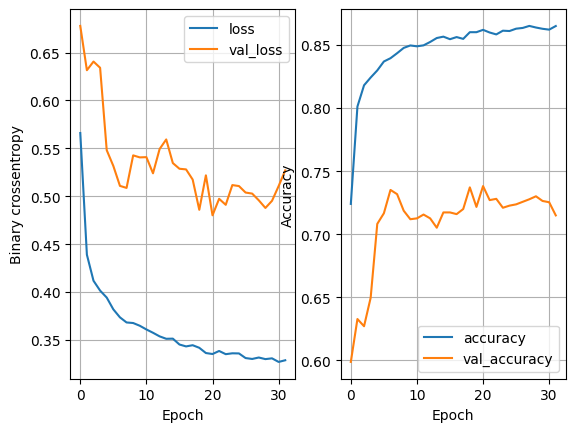

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8628 - loss: 0.3268
32nodes,dropout=0.2,Learning Rate=0.001,Batch Size=64


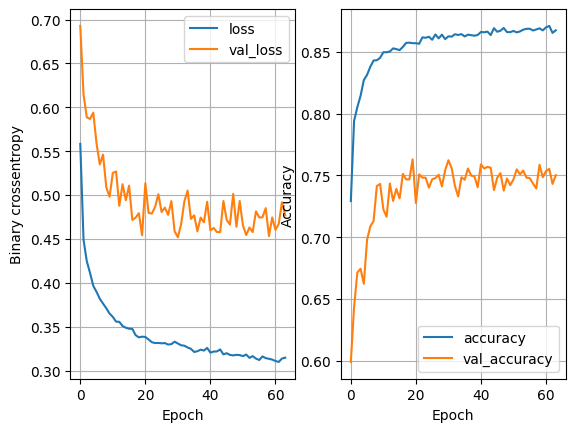

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8659 - loss: 0.3157
32nodes,dropout=0.2,Learning Rate=0.001,Batch Size=128


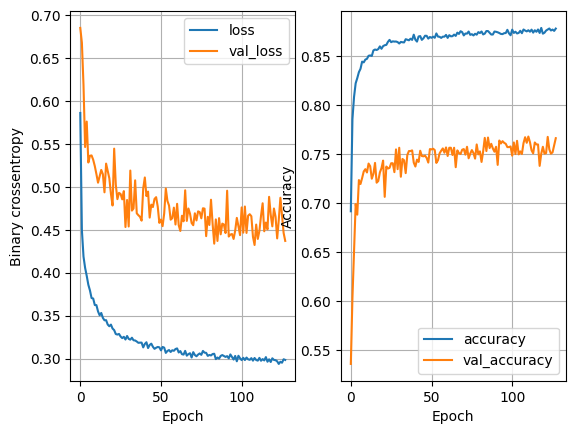

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8683 - loss: 0.3129
64nodes,dropout=0,Learning Rate=0.01,Batch Size=32


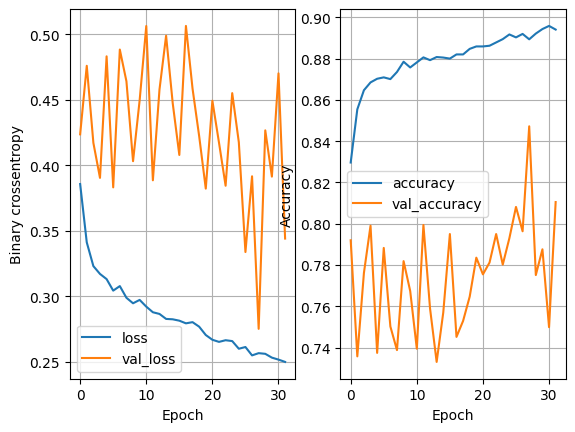

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8675 - loss: 0.3609
64nodes,dropout=0,Learning Rate=0.01,Batch Size=64


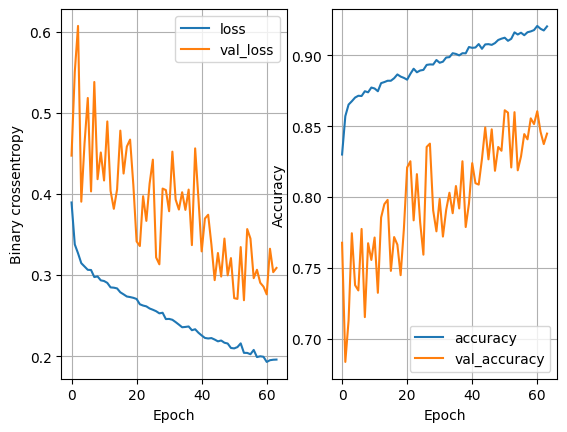

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8573 - loss: 0.4534
64nodes,dropout=0,Learning Rate=0.01,Batch Size=128


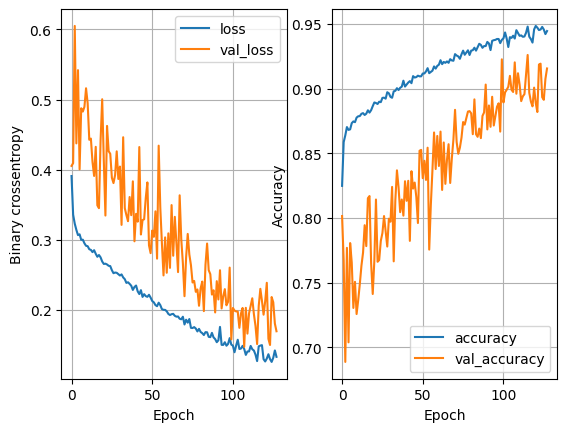

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8573 - loss: 0.7122
64nodes,dropout=0,Learning Rate=0.005,Batch Size=32


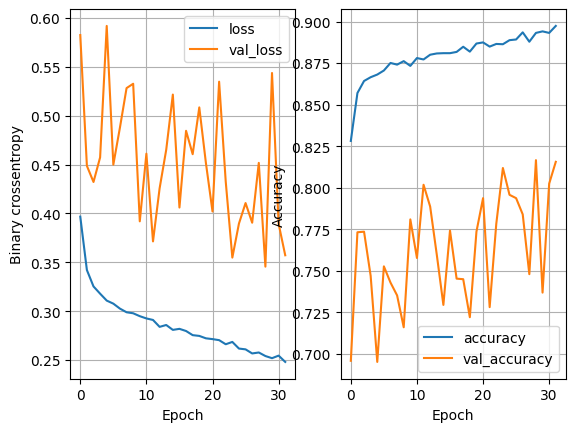

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8649 - loss: 0.3331
64nodes,dropout=0,Learning Rate=0.005,Batch Size=64


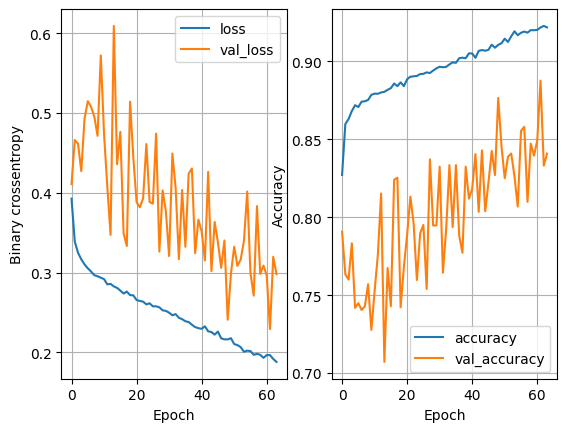

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8609 - loss: 0.3904
64nodes,dropout=0,Learning Rate=0.005,Batch Size=128


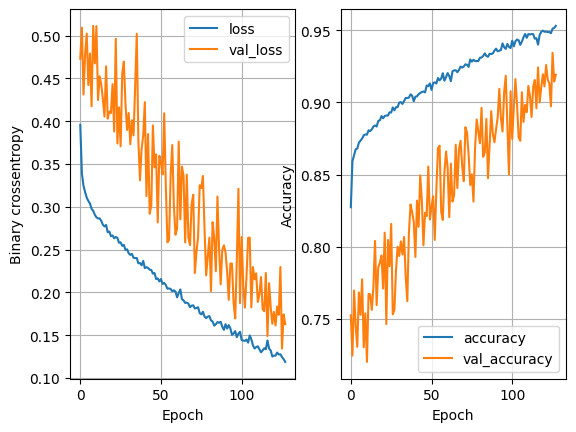

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8420 - loss: 0.6662
64nodes,dropout=0,Learning Rate=0.001,Batch Size=32


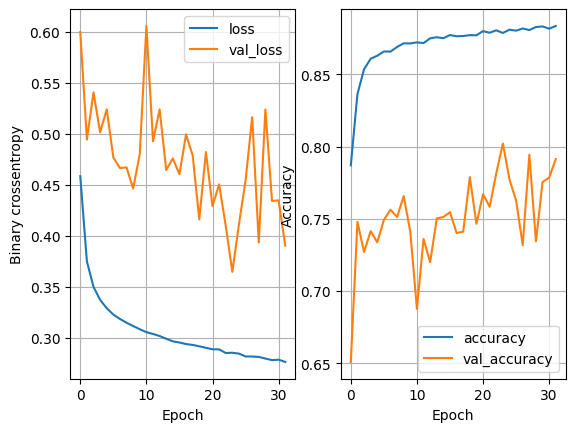

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8680 - loss: 0.3199
64nodes,dropout=0,Learning Rate=0.001,Batch Size=64


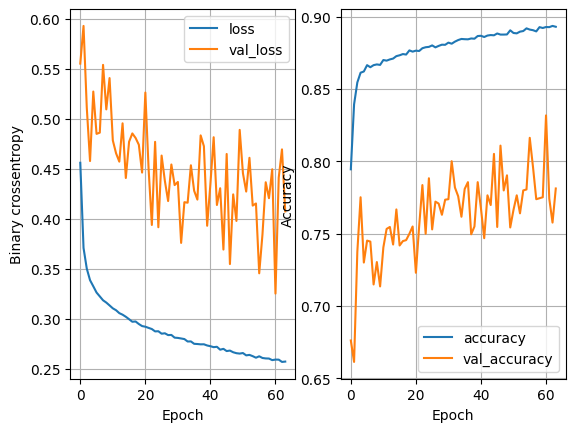

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8722 - loss: 0.3170
64nodes,dropout=0,Learning Rate=0.001,Batch Size=128


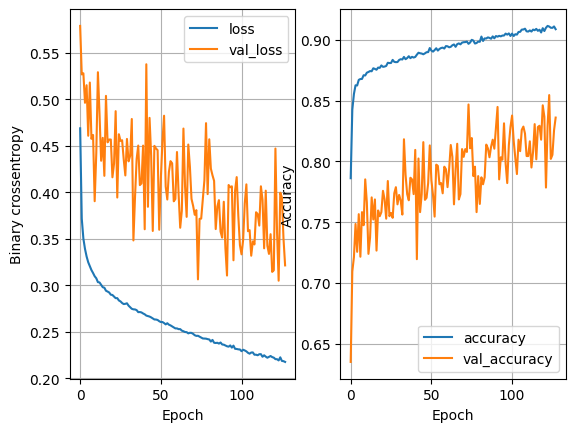

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8591 - loss: 0.3476
64nodes,dropout=0.2,Learning Rate=0.01,Batch Size=32


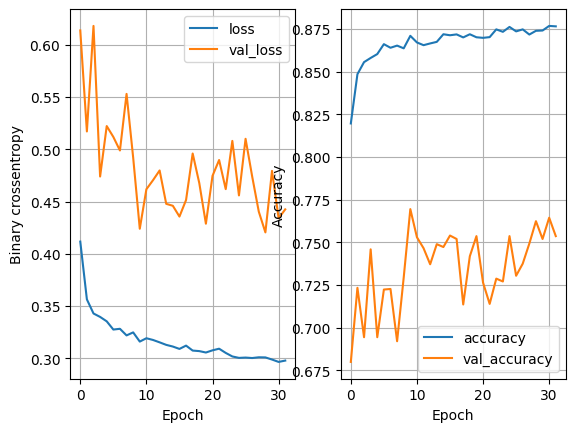

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8715 - loss: 0.3186
64nodes,dropout=0.2,Learning Rate=0.01,Batch Size=64


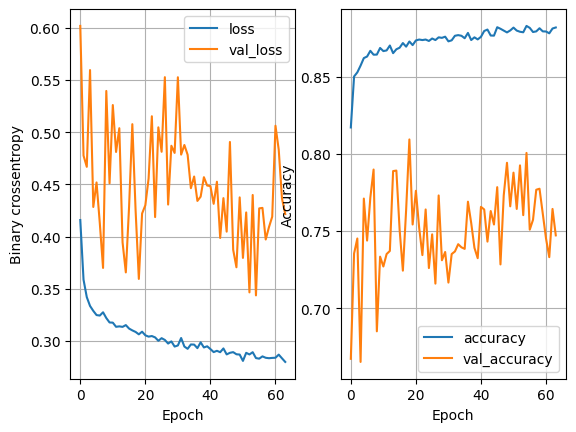

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8725 - loss: 0.3124
64nodes,dropout=0.2,Learning Rate=0.01,Batch Size=128


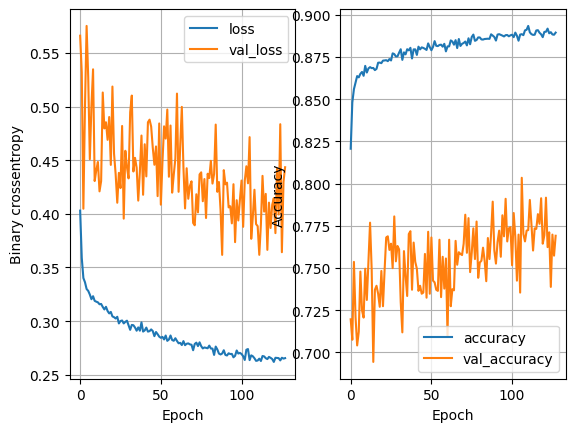

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8746 - loss: 0.3203
64nodes,dropout=0.2,Learning Rate=0.005,Batch Size=32


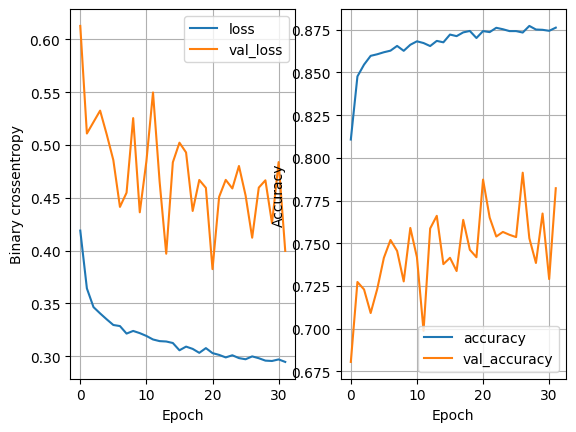

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8657 - loss: 0.3158
64nodes,dropout=0.2,Learning Rate=0.005,Batch Size=64


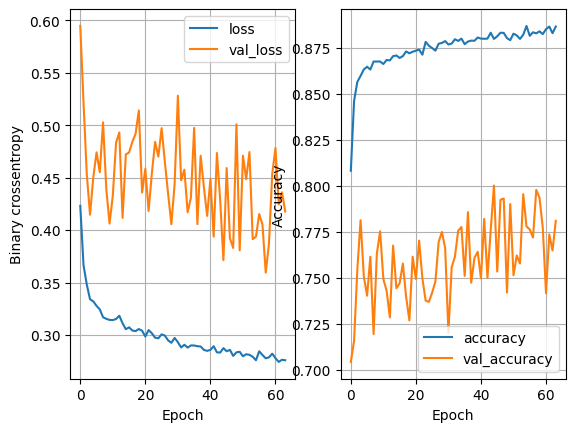

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8722 - loss: 0.3105
64nodes,dropout=0.2,Learning Rate=0.005,Batch Size=128


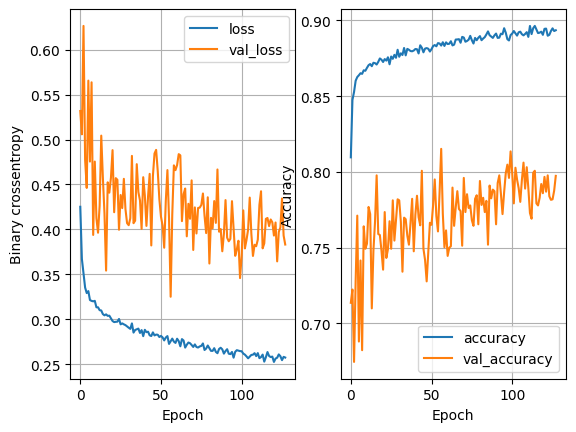

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8759 - loss: 0.3155
64nodes,dropout=0.2,Learning Rate=0.001,Batch Size=32


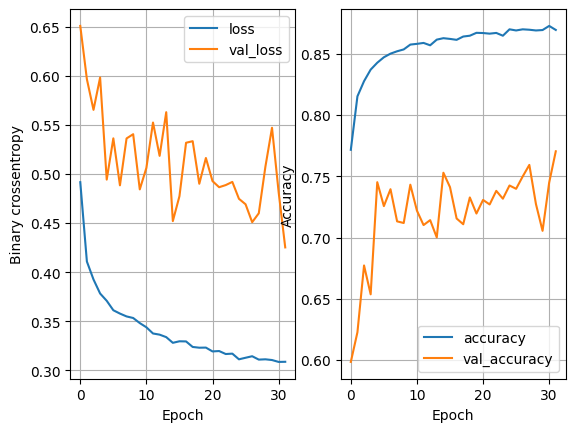

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8704 - loss: 0.3156
64nodes,dropout=0.2,Learning Rate=0.001,Batch Size=64


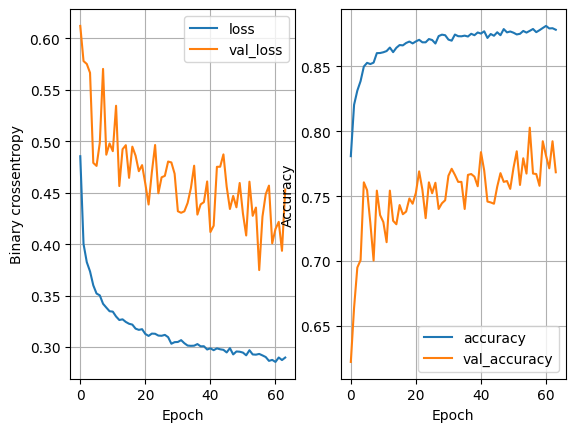

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8736 - loss: 0.3093
64nodes,dropout=0.2,Learning Rate=0.001,Batch Size=128


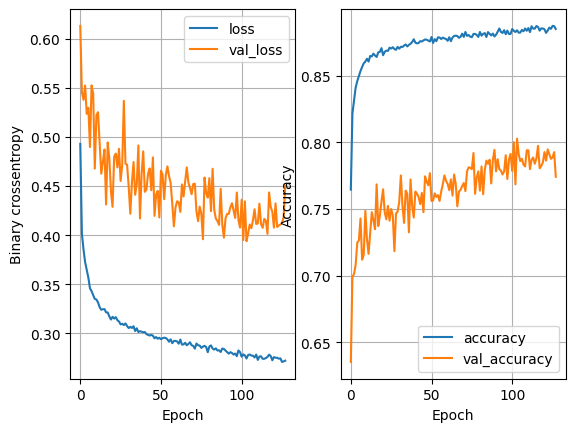

119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8733 - loss: 0.3051


In [ ]:
#Now as we Defined a Function called train_model lets play with hyperparameters a little to see effect of
#them in real life senarios
least_val_loss=float('inf')
best_model=None
epochs=100
for num_nodes in[16,32,64]:
  for dropout_prob in[0,0.2]:
    for lr in [0.01,0.005,0.001]:
      for batch_size in[32,64,128]:
        print(f"{num_nodes}nodes,dropout={dropout_prob},Learning Rate={lr},Batch Size={batch_size}")
        model,history =train_model(X_train,Y_train,num_nodes,dropout_prob,lr,batch_size,epochs)
        plot_history(history)
        val_loss=model.evaluate(X_valid,Y_valid)[0]
        if val_loss < least_val_loss:
          least_val_loss=val_loss
          best_model=model




In [ ]:
print(least_val_loss)
best_model.summary()
'''
From running all combinations we conclude that best model is
with hyperaparameteres :
  64nodes,dropout=0.2,Learning Rate=0.001,Batch Size=128
  '''


0.30511710047721863


Model: "sequential_56"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_168 (Dense)               │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_110 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_169 (Dense)               │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_111 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_170 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,789 (57.77 KB)

 Trainable params: 4,929 (19.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 9,860 (38.52 KB)

'\nFrom running all combinations we conclude that best model is \nwith hyperaparameteres :\n  64nodes,dropout=0.2,Learning Rate=0.001,Batch Size=128\n  '

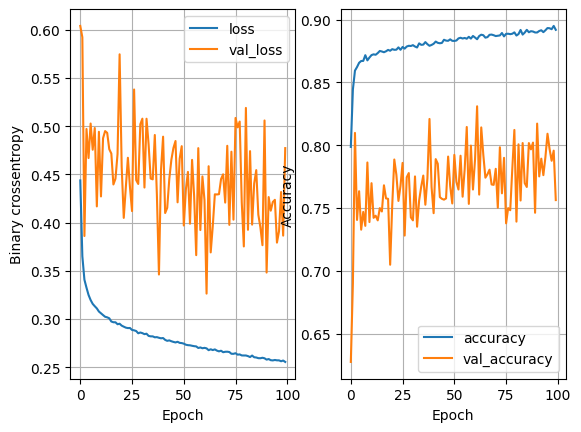

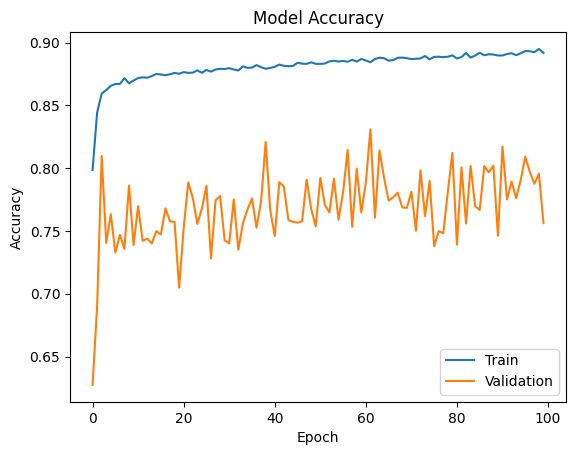

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])
plt.show()

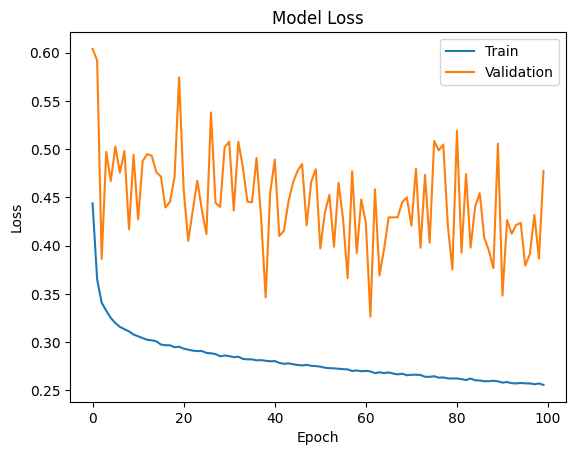

In [ ]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])
plt.show()